# 如何通过中介分析筛选关键代谢物
本文主要是根据今年发表在Nature Metabolism的文章来学习，在众多代谢物中如何筛选暴露跟结局相关的关键代谢物。文章大致的思路是，研究发现暴露跟结局显著相关，然后通过暴露和代谢物浓度矩阵构建稀疏偏最小二乘（sPLS）模型，给每个样本评估代谢组评分，来给每个代谢物进行打分，也可以说计算每个代谢物的权重or贡献度，本质上代谢组评分计算方法为：Metabolite score(MS) = Σ(代谢物浓度 × 对应权重系数)。最终通过将代谢评分加入到中介分析中，通过不断逆向淘汰循环代谢物，使得中介效应（ACME）反而最大的情况下，只保留关键代谢物。最终得到一些关键的代谢物，并计算最终的代谢组评分，代入中介分析，得到中介效应值。

注：sPLS是caret R包中的方法，一种特别适用于高维数据（变量多、样本量相对少）的回归方法，它可以同时进行变量筛选和降维。

# 文章概述
- 标题: 孕期西方饮食模式与儿童及青少年神经发育障碍相关
- 期刊: 《Nature Metabolism》
- 核心发现: 本研究通过多个大型母婴队列研究发现，母亲在孕期（尤其是在孕早中期）遵循高加工肉类、高糖、高精制谷物的“西方饮食模式”，会显著增加子代患ADHD和自闭症的风险及症状严重程度。研究还通过血液代谢组学识别出15种可能介导此关联的代谢物，并发现这种关联在具有较高遗传风险和高体重指数（BMI）母亲所生的男孩中尤为明显。

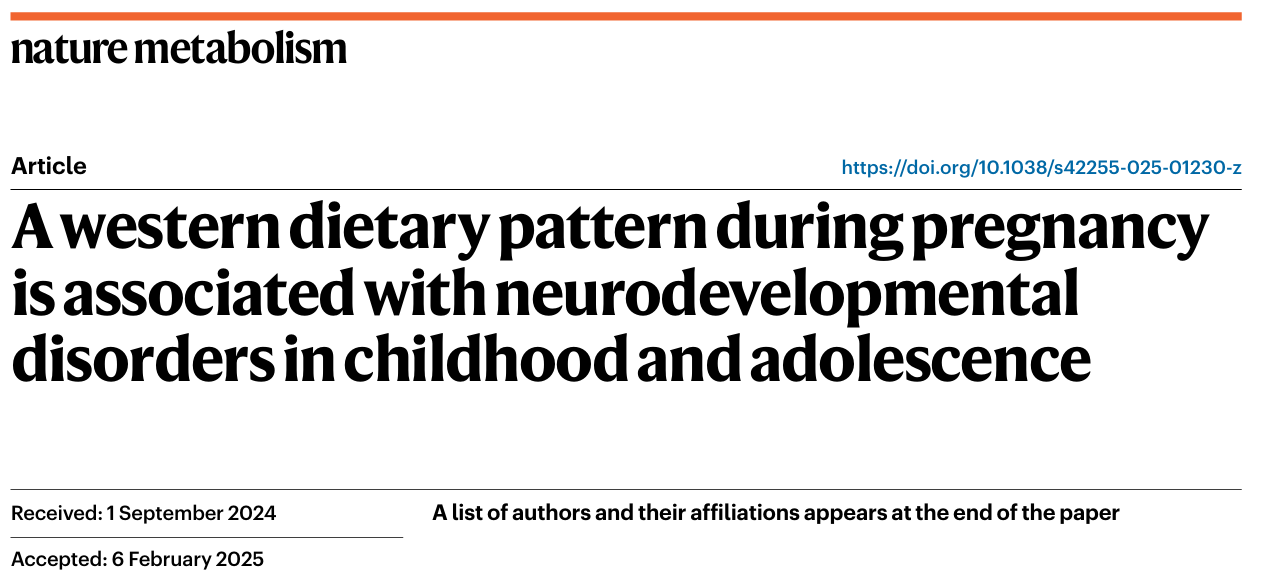

# 背景：
- 神经发育障碍（如ADHD、自闭症）非常普遍，但母亲孕期饮食对子代神经发育的影响研究不足。

# 方法：
- 发现队列: 使用COPSAC2010队列（n=508），分析母亲孕24周自述的饮食模式和子代10岁时经临床评估的神经发育障碍。
- 验证队列: 在三个独立的大型队列（总人数超过6万）中通过不同的方法（自我报告饮食模型、母亲血液代谢组学、胎儿血液代谢组学）验证主要发现。

# 核心发现：
- 关联性: 孕期西方饮食模式与子代ADHD和自闭症诊断显著相关。
- 代谢物介导: 发现了15种在孕期可能介导这种关联的代谢物，它们能改善对ADHD的预测。
- 关键窗口期: 纵向代谢组分析表明，孕早中期是饮食影响神经发育的特别敏感时期。
- 效应修饰: 这种关联在遗传风险高、母亲孕前BMI高的子代中更强。
  
# 意义: 
- 研究结果强调了针对性的产前饮食干预在预防神经发育障碍方面的潜力，并突出了早期干预的重要性。

# 以下将是我个人对部分代码的理解与整理
- 1. 数据的预处理和加载
- 2. 稀疏偏最小二乘（sPLS）模型构建与代谢组评分计算

##  1. 数据预处理与加载
```R
# 加载必要的包
library(caret)        # 机器学习框架
library(missForest)   # 随机森林插补
library(tidyverse)    # 数据清洗和可视化
library(glmnet)       # 正则化回归
library(pROC)         # ROC曲线分析
library(readxl)
# 设置随机种子保证结果可重复
set.seed(123)

# 构建一个函数来处理数据
processing_data_fun <- function(inputfile, sample_type, outcome_col, expose_col) {
  # inputfile: 数据文件路径
  # sample_type: 样本类型（需要分析的样本类型）
  # outcome_col: 结局变量列名
  # expose_col: 饮食评分列名

  # 数据结构：第43列后为代谢物数据，前面为其他信息（包括暴露，结局和其他协变量）
  data <- read_excel(inputfile)
  # 选择样本类型
  metabolic_data = data[data$Sample_type==sample_type,]
  
  metabolic_data <- metabolic_data[complete.cases(metabolic_data[, outcome_col]), ]
  metabolic_data <- metabolic_data[complete.cases(metabolic_data[, expose_col]), ]
  
  # 检查数据基本信息
  cat("数据维度:", dim(metabolic_data), "\n")
  cat("饮食评分缺失值:", sum(is.na(metabolic_data[,expose_col])), "\n")
  cat("结局变量缺失值:", sum(is.na(metabolic_data[,outcome_col])), "\n")
  cat("代谢物缺失值比例:\n")
  summary(colSums(is.na(metabolic_data[,43:ncol(metabolic_data)]))/nrow(metabolic_data))
  
  # 删除代谢物缺失率过高的样本（>50%）
  missing_per_sample <- rowSums(is.na(metabolic_data[,43:ncol(metabolic_data)]))/(ncol(metabolic_data) - 43+1)
  metabolic_data <- metabolic_data[missing_per_sample <= 0.5, ]
  
  # # 删除缺失率过高的代谢物（>30%）
  # missing_per_metabolite <- colSums(is.na(metabolic_data[,37:724]))/nrow(metabolic_data)
  # keep_metabolites <- which(missing_per_metabolite <= 0.3) + 2
  # metabolic_data <- metabolic_data[, c(1,2,keep_metabolites)]
  
  cat("预处理后数据维度:", dim(metabolic_data), "\n")
  
  summary(metabolic_data)
  
  ##################  3. 缺失值插补和标准化
  # 对代谢物数据进行随机森林插补
  metabolites_only <- metabolic_data[, 43:ncol(metabolic_data)]
  if (min(metabolites_only, na.rm = TRUE) < 0) {
    delta <- -min(metabolites_only, na.rm = TRUE)   # 需要平移的量
    metabolites_only <- metabolites_only + delta
  }
  # 使用随机森林插补缺失值
  rf_imputed <- missForest(metabolites_only, verbose = TRUE)
  metabolites_imputed <- rf_imputed$ximp
  
  # 对数转换（处理偏态分布）
  summary(metabolites_imputed)
  
  metabolites_log <- log(metabolites_imputed + 1e-10) 
  # 标准化（均值为0，标准差为1）
  metabolites_scaled <- scale(metabolites_log)
  # 重建完整数据集
  final_data <- data.frame(
    diet_score = metabolic_data[,expose_col],
    outcome = factor(as.integer(metabolic_data[[outcome_col]])),
    # 其他协变量
    Mage_G = metabolic_data[,"Mage_G"],
    mincomegroup = metabolic_data[,"mincomegroup"],
    preBMI_gct = metabolic_data[,"preBMI_gct"],
    medugroup =  metabolic_data[,"medugroup"],
    Smoke =  metabolic_data[,'Smoke'],
    metabolites_scaled
  )
  return(final_data)
}

```

## 稀疏偏最小二乘（sPLS）模型构建与代谢组评分计算
```r
module_processing_fun <- function(final_data, expose_col, outcome_col ,  MCtype = MCtype){
  # final_data: 包含所有样本的处理后的数据
  # expose_col: 结局变量列名
  # outcome_col: 代谢物评分列名
  # MCtype: 样本类型
  
  # 设置交叉验证参数
  train_control <- trainControl(
    method = "repeatedcv",
    number = 5,           # 5折交叉验证
    repeats = 10,          # 重复10次
    savePredictions = "final",
    allowParallel = TRUE,
    verboseIter = FALSE
  )
  
  # 准备建模数据
  X <- final_data[, 8:ncol(final_data)]  # 代谢物数据
  y <- final_data[[expose_col]]             # 暴露变量
  
  model_data <- data.frame(diet_score = y, X)
  
  # 移除零方差的代谢物（对模型无贡献）
  nzv <- nearZeroVar(X)
  if(length(nzv) > 0) {
    model_data <- model_data[, -(nzv + 1)]  # +1因为第一列是暴露
  }
  
  colSums(is.na(model_data))   # 每列 NA 个数
  which(is.na(model_data), arr.ind = TRUE)
  # 1. 去掉含 NA 的行（最简单、最常用）
  model_data <- na.omit(model_data)
  
  # 训练sPLS模型
  spls_model <- train(
    diet_score ~ .,
    data = model_data,
    method = "spls",
    preProc = c("center", "scale"),
    tuneGrid = expand.grid(
      K = 1:3,              # 尝试1-3个成分，运行慢可以只选择1个
      eta = seq(0.1, 0.9, 0.2),  # 稀疏参数
      kappa = 0.5
    ),
    trControl = train_control,
    metric = "RMSE"
  )
  
  # 查看最优参数
  cat("最优模型参数:\n")
  print(spls_model$bestTune)
  
  #############5. 代谢组评分（MS）计算
  # 提取最优模型
  best_model <- spls_model$finalModel
  
  # 计算每个样本的WDP-MS评分
  WDP_MS_scores <- predict(spls_model, newdata = model_data)
  
  # 将评分添加到数据集中
  final_data$WDP_MS <- as.numeric(WDP_MS_scores)
  
  # 标准化WDP-MS评分（均值为0，标准差为1）
  final_data$WDP_MS_scaled <- scale(final_data$WDP_MS)
  
  # 查看评分分布
  cat("WDP-MS评分统计摘要:\n")
  summary(final_data$WDP_MS_scaled)
  
  
  # ########### 6. 代谢物重要性分析
  # 提取代谢物的权重系数
  # X <- model_data[, 2:ncol(model_data)]  # 代谢物数据
  tmp_res <- try({if("spls" %in% class(best_model)) {
    # 提取变量权重
    variable_weights <- best_model$projection
    
    # 创建代谢物重要性数据框
    metabolite_importance <- data.frame(
      metabolite = colnames(X),
      weight = as.numeric(variable_weights),
      abs_weight = abs(as.numeric(variable_weights))
    ) %>%
      arrange(desc(abs_weight))
    
    # 显示最重要的20个代谢物
    # cat("最重要的20个代谢物:\n")
    # print(head(metabolite_importance, 20))
  }
  write.csv(metabolite_importance, paste0(outcome_col,"_",MCtype, "_",expose_col, ".weights.csv"),row.names = FALSE)
  }, silent = TRUE)          # silent = TRUE 抑制错误信息打印

  # 7. MS与结局变量关联分析
  
  # 逻辑回归分析MS与结局的关系
  outcome_model <- glm(
    outcome ~ WDP_MS_scaled + Mage_G + mincomegroup + 
              preBMI_gct + medugroup + Smoke,
    data = final_data,
    family = binomial()
   )
  
  # 提取详细的模型结果
  model_summary <- summary(outcome_model)
  coefficient <- coef(outcome_model)[2]
  std_error <- coef(model_summary)[2, "Std. Error"]
  z_value <- coef(model_summary)[2, "z value"]
  p_value <- coef(model_summary)[2, "Pr(>|z|)"]
  
  # 计算OR值及置信区间
  OR <- exp(coefficient)
  OR_CI_lower <- exp(coefficient - 1.96 * std_error)
  OR_CI_upper <- exp(coefficient + 1.96 * std_error)
  
  
  cat("WDP-MS每增加1个SD，结局风险的OR值:", round(OR, 3), "\n")
  cat("95%置信区间:", round(c(OR_CI_lower, OR_CI_upper), 3), "\n")
  
  # ROC曲线分析
  roc_obj <- roc(final_data$outcome, final_data$WDP_MS_scaled)
  auc_value <- auc(roc_obj)
  auc_ci <- ci.auc(roc_obj)
  cat("AUC值:", round(auc_value, 3), "\n")
  
  
  
  ######  9. 模型性能评估
  
  # 交叉验证性能
  cat("模型交叉验证性能:\n")
  print(spls_model$results %>% arrange(RMSE) %>% head(5))
  
  # 预测值与真实值的相关性
  correlation <- cor(final_data[[expose_col]], final_data$WDP_MS, use = "complete.obs")
  cat("WDP-MS与原始饮食评分的相关性:", round(correlation, 3), "\n")
  
  # # 保存结果
  # results <- list(
  # model = spls_model,
  # WDP_MS_scores = final_data$WDP_MS_scaled,
  # metabolite_importance = metabolite_importance,
  # outcome_association = summary(outcome_model),
  # AUC = auc_value,
  # correlation = correlation
  # )
  # 创建结果数据框
  results_df <- data.frame(
    Variable = "WDP_MS_scaled",
    expose = expose_col,
    outcome = outcome_col,
    type = MCtype,
    OR = round(OR, 3),
    OR_CI_Lower = round(OR_CI_lower, 3),
    OR_CI_Upper = round(OR_CI_upper, 3),
    Coefficient = round(coefficient, 4),
    Std_Error = round(std_error, 4),
    Z_Value = round(z_value, 3),
    P_Value = format.pval(p_value, digits = 3, eps = 0.001),
    AUC = round(auc_value, 3),
    AUC_CI_Lower = round(auc_ci[1], 3),
    AUC_CI_Upper = round(auc_ci[3], 3),
    Sample_Size = nrow(final_data),
    Cases = sum(final_data$outcome == 1),
    Controls = sum(final_data$outcome == 0),
    stringsAsFactors = FALSE,
    correlation = correlation
  )
  
  # 保存结果到CSV文件
  write.csv(results_df, paste0(outcome_col,"_",MCtype, "_",expose_col, ".res.csv"), row.names = FALSE)
  # 保存重要结果到文件
  write.csv(final_data, paste0(outcome_col,"_",MCtype, "_",expose_col, ".analysis_results.csv"), row.names = FALSE)
  tmp_res2 <- try({write.csv(metabolite_importance, paste0(outcome_col,"_",MCtype, "_",expose_col, ".weights.csv"),row.names = FALSE)
  }, silent = TRUE)
  if (inherits(tmp_res2, "try-error")) next   # 报错就跳过
  list(results_df=results_df, final_data=final_data)
  
}
```